In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -1 Data Set

In [2]:
loan = pd.read_csv('loan-train.csv')

In [3]:
loan.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [4]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1614 entries, 0 to 1613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            1614 non-null   object 
 1   Gender             1601 non-null   object 
 2   Married            1611 non-null   object 
 3   Dependents         1599 non-null   object 
 4   Education          1614 non-null   object 
 5   Self_Employed      1582 non-null   object 
 6   ApplicantIncome    1614 non-null   int64  
 7   CoapplicantIncome  1614 non-null   float64
 8   LoanAmount         1592 non-null   float64
 9   Loan_Amount_Term   1600 non-null   float64
 10  Credit_History     1564 non-null   float64
 11  Property_Area      1614 non-null   object 
 12  Loan_Status        1614 non-null   object 
dtypes: float64(4), int64(1), object(8)
memory usage: 164.1+ KB


In [5]:
loan.drop_duplicates(subset=['Loan_ID'], inplace=True)

In [6]:
loan.Gender.unique()

array(['Male', 'Female', nan], dtype=object)

In [7]:
loan.Gender.isna().sum()

np.int64(13)

In [8]:
loan.isna().mean()*100

Loan_ID              0.000000
Gender               0.845254
Married              0.195059
Dependents           0.975293
Education            0.000000
Self_Employed        2.080624
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           1.430429
Loan_Amount_Term     0.910273
Credit_History       3.250975
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [9]:
loan.fillna(loan.Gender.mode()[0], inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_3776\430423207.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Male' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  loan.fillna(loan.Gender.mode()[0], inplace=True)


In [10]:
loan.Married.unique()

array(['No', 'Yes', 'Male'], dtype=object)

In [11]:
(loan.Married == 'Male').sum()

np.int64(3)

In [12]:
loan.Married = loan.Married.replace('Male',None)

In [13]:
loan.Married.unique()

array(['No', 'Yes', None], dtype=object)

In [14]:
loan.isna().sum()

Loan_ID              0
Gender               0
Married              3
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [15]:
loan[loan.Married.isna()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
104,LP001357,Male,None,Male,Graduate,No,3816,754.0,160.0,360.0,1.0,Urban,Y
228,LP001760,Male,None,Male,Graduate,No,4758,0.0,158.0,480.0,1.0,Semiurban,Y
435,LP002393,Female,None,Male,Graduate,No,10047,0.0,Male,240.0,1.0,Semiurban,Y


In [16]:
loan.dropna(subset=['Married'],inplace=True)

In [17]:
loan.Dependents = loan.Dependents.replace('Male', None)
loan.Dependents = loan.Dependents.map({'0':0,'1':1,'2':2,'3+':3})

In [18]:
loan.Dependents.isna().sum()

np.int64(12)

In [19]:
loan.Dependents = loan['Dependents'].fillna(loan['Married'].map({'Yes':1}))

In [20]:
loan[loan.Dependents.isna()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
293,LP001945,Female,No,NaN,Graduate,No,5417,0.0,143.0,480.0,0.0,Urban,N
332,LP002100,Male,No,NaN,Graduate,No,2833,0.0,71.0,360.0,1.0,Urban,Y
355,LP002144,Female,No,NaN,Graduate,No,3813,0.0,116.0,180.0,1.0,Urban,Y
597,LP002943,Male,No,NaN,Graduate,No,2987,0.0,88.0,360.0,0.0,Semiurban,N


In [21]:
loan.Dependents = loan['Dependents'].fillna(loan['Married'].map({'No':0}))

In [22]:
loan.Dependents.isna().sum()

np.int64(0)

In [23]:
loan.Dependents = loan.Dependents.astype(int)

In [24]:
loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,Male,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [25]:
loan.Education.unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [26]:
loan.Self_Employed.unique()

array(['No', 'Yes', 'Male'], dtype=object)

In [27]:
loan.Self_Employed = loan.Self_Employed.replace('Male', None)
loan.Self_Employed.isna().sum()

np.int64(32)

In [28]:
loan.Self_Employed.isna().mean()*100

np.float64(2.0846905537459284)

In [29]:
loan['Self_Employed'] = loan['Self_Employed'].fillna(loan['Married'].map({'Yes':'Graduate', 'No':'Not Graduate'}))
loan['Self_Employed'].isna().sum()

np.int64(0)

In [30]:
loan.ApplicantIncome.isna().sum()
loan.ApplicantIncome.dtype

dtype('int64')

In [31]:
loan.CoapplicantIncome = loan.CoapplicantIncome.astype(int)

In [32]:
loan.LoanAmount.dtype
loan.LoanAmount = pd.to_numeric(loan.LoanAmount, errors='coerce')
loan.LoanAmount.isna().sum()
loan.LoanAmount.isna().mean()*100

np.float64(1.3680781758957654)

In [33]:
loan.LoanAmount.isna().sum()

np.int64(21)

In [34]:
loan.LoanAmount.isna().sum()

np.int64(21)

In [35]:
loan['Income_Category'] = pd.qcut(loan.ApplicantIncome, q=4, labels=['Low Income', 'Average Income', 'Normal Income', 'Handsome Income'])

In [36]:
loan.LoanAmount

0         NaN
1       128.0
2        66.0
3       120.0
4       141.0
        ...  
1609    323.0
1610    182.0
1611    222.0
1612    355.0
1613    463.0
Name: LoanAmount, Length: 1535, dtype: float64

In [37]:
loan.LoanAmount.fillna(loan.groupby('Income_Category')['LoanAmount'].transform('median'), inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_3776\2261940563.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loan.LoanAmount.fillna(loan.groupby('Income_Category')['LoanAmount'].transform('median'), inplace=True)


In [38]:
loan.LoanAmount.isna().sum() 

np.int64(0)

In [39]:
loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Income_Category
0,LP001002,Male,No,0,Graduate,No,5849,0,158.0,360.0,1.0,Urban,Y,Average Income
1,LP001003,Male,Yes,1,Graduate,No,4583,1508,128.0,360.0,1.0,Rural,N,Average Income
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0,66.0,360.0,1.0,Urban,Y,Low Income
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358,120.0,360.0,1.0,Urban,Y,Low Income
4,LP001008,Male,No,0,Graduate,No,6000,0,141.0,360.0,1.0,Urban,Y,Average Income


In [40]:
loan.Loan_Amount_Term = loan.Loan_Amount_Term.replace('Male', None)
loan.Loan_Amount_Term.isna().sum()

np.int64(14)

In [41]:
loan.Loan_Amount_Term.unique()

array([360.0, 120.0, 240.0, None, 180.0, 60.0, 300.0, 480.0, 36.0, 84.0,
       12.0], dtype=object)

In [42]:
loan['Loan_Amount_Term'] = pd.to_numeric(loan['Loan_Amount_Term'], errors='coerce')

In [43]:
loan.Credit_History.unique()

array([1.0, 0.0, 'Male'], dtype=object)

In [44]:
loan['Credit_History'] = pd.to_numeric(loan['Credit_History'], errors='coerce')

In [45]:
loan.Credit_History.unique()

array([ 1.,  0., nan])

In [46]:
loan.Loan_Amount_Term.isna().sum(

)

np.int64(14)

In [47]:
mapping = {1.0: 360.0, 0.0: 12.0}

loan['Loan_Amount_Term'] = loan['Loan_Amount_Term'].fillna(loan['Credit_History'].map(mapping))

In [48]:
loan

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Income_Category
0,LP001002,Male,No,0,Graduate,No,5849,0,158.0,360.0,1.0,Urban,Y,Average Income
1,LP001003,Male,Yes,1,Graduate,No,4583,1508,128.0,360.0,1.0,Rural,N,Average Income
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0,66.0,360.0,1.0,Urban,Y,Low Income
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358,120.0,360.0,1.0,Urban,Y,Low Income
4,LP001008,Male,No,0,Graduate,No,6000,0,141.0,360.0,1.0,Urban,Y,Average Income
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1609,LP009965,Male,No,3,Graduate,Yes,13658,9822,323.0,180.0,0.0,Urban,N,Handsome Income
1610,LP009966,Male,Yes,0,Graduate,No,13683,2223,182.0,360.0,1.0,Semiurban,Y,Handsome Income
1611,LP009970,Male,Yes,3,Not Graduate,Yes,19409,768,222.0,360.0,0.0,Urban,N,Handsome Income
1612,LP009977,Female,Yes,2,Graduate,Yes,8997,1354,355.0,360.0,0.0,Rural,Y,Normal Income


In [49]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1535 entries, 0 to 1613
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Loan_ID            1535 non-null   object  
 1   Gender             1535 non-null   object  
 2   Married            1535 non-null   object  
 3   Dependents         1535 non-null   int64   
 4   Education          1535 non-null   object  
 5   Self_Employed      1535 non-null   object  
 6   ApplicantIncome    1535 non-null   int64   
 7   CoapplicantIncome  1535 non-null   int64   
 8   LoanAmount         1535 non-null   float64 
 9   Loan_Amount_Term   1535 non-null   float64 
 10  Credit_History     1485 non-null   float64 
 11  Property_Area      1535 non-null   object  
 12  Loan_Status        1535 non-null   object  
 13  Income_Category    1535 non-null   category
dtypes: category(1), float64(3), int64(3), object(7)
memory usage: 169.6+ KB


In [50]:
loan.Credit_History.isna().sum()

np.int64(50)

In [51]:
loan.Credit_History.fillna(loan.Loan_Status.map({'Y':1.0,'N':0.0 }), inplace=True)
loan.Credit_History.isna().sum()

C:\Users\HP\AppData\Local\Temp\ipykernel_3776\3032960131.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan.Credit_History.fillna(loan.Loan_Status.map({'Y':1.0,'N':0.0 }), inplace=True)


np.int64(0)

In [52]:
loan.Credit_History = loan.Credit_History.astype(int)

In [53]:
loan.Property_Area.unique()
loan.Property_Area.isna().sum()

np.int64(0)

In [54]:
loan.Loan_Status.unique()

array(['Y', 'N'], dtype=object)

In [55]:
loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Income_Category
0,LP001002,Male,No,0,Graduate,No,5849,0,158.0,360.0,1,Urban,Y,Average Income
1,LP001003,Male,Yes,1,Graduate,No,4583,1508,128.0,360.0,1,Rural,N,Average Income
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0,66.0,360.0,1,Urban,Y,Low Income
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358,120.0,360.0,1,Urban,Y,Low Income
4,LP001008,Male,No,0,Graduate,No,6000,0,141.0,360.0,1,Urban,Y,Average Income


In [56]:
loan.Married.value_counts()

Married
Yes    884
No     651
Name: count, dtype: int64

In [57]:
loan.Gender.value_counts()

Gender
Male      951
Female    584
Name: count, dtype: int64

In [58]:
loan.groupby('Married')['Gender'].count()

Married
No     651
Yes    884
Name: Gender, dtype: int64

In [59]:
gen_mar = loan.groupby(['Gender','Married']).size().reset_index(name='count')
gen_mar

,Gender,Married,count
0,Female,No,299
1,Female,Yes,285
2,Male,No,352
3,Male,Yes,599


<Axes: xlabel='Married', ylabel='count'>

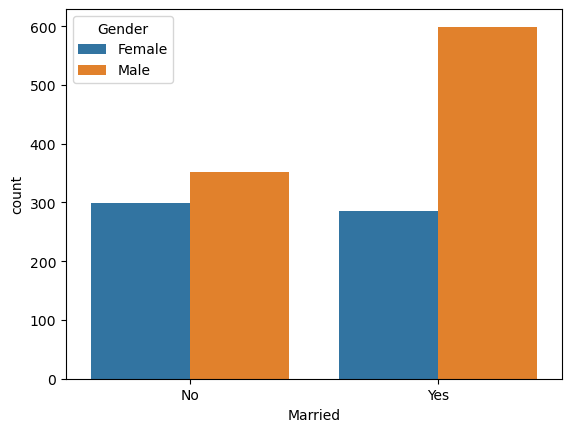

In [60]:
sns.barplot(data=gen_mar, x='Married', y='count', hue='Gender')

In [61]:
loan.Self_Employed = loan.Self_Employed.map({'No':'No', 'Yes':'Yes', 'Graduate':None, 'Not Graduate':None})
loan.Self_Employed.fillna(loan.Loan_Status.map({'Y':'Yes', 'N':'No'}), inplace=True)
loan.Self_Employed.isna().sum()

C:\Users\HP\AppData\Local\Temp\ipykernel_3776\1312733308.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan.Self_Employed.fillna(loan.Loan_Status.map({'Y':'Yes', 'N':'No'}), inplace=True)


np.int64(0)

In [62]:
gen_selfemp = loan.groupby(['Gender', 'Self_Employed']).size().reset_index(name='count')

In [63]:
gen_selfemp

,Gender,Self_Employed,count
0,Female,No,335
1,Female,Yes,249
2,Male,No,628
3,Male,Yes,323


<Axes: xlabel='Self_Employed', ylabel='count'>

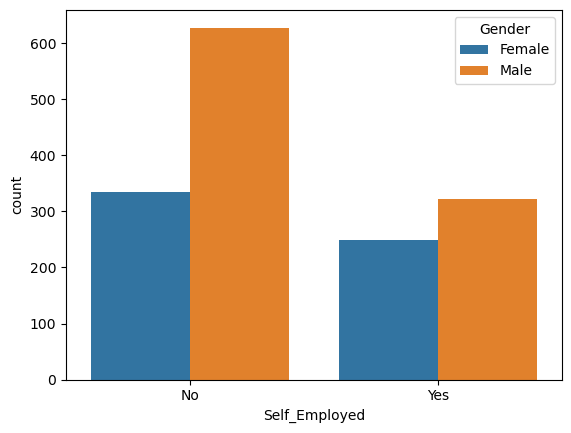

In [64]:
sns.barplot(data=gen_selfemp, x='Self_Employed', y='count', hue='Gender' )

In [65]:
edu_self = pd.crosstab(loan.Education, loan.Self_Employed).reset_index()
edu_self

Self_Employed,Education,No,Yes
0,Graduate,594,317
1,Not Graduate,369,255


In [66]:
edu_selfemp = pd.melt(id_vars='Education', value_vars=['No','Yes'], var_name= 'Self_Employed',value_name='count', frame=edu_self)
edu_selfemp

,Education,Self_Employed,count
0,Graduate,No,594
1,Not Graduate,No,369
2,Graduate,Yes,317
3,Not Graduate,Yes,255


<Axes: xlabel='Self_Employed', ylabel='count'>

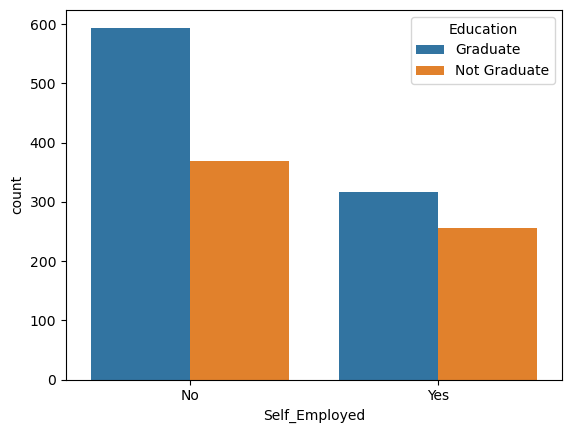

In [67]:
sns.barplot(data=edu_selfemp, x='Self_Employed', y='count', hue='Education')

In [68]:
loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Income_Category
0,LP001002,Male,No,0,Graduate,No,5849,0,158.0,360.0,1,Urban,Y,Average Income
1,LP001003,Male,Yes,1,Graduate,No,4583,1508,128.0,360.0,1,Rural,N,Average Income
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0,66.0,360.0,1,Urban,Y,Low Income
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358,120.0,360.0,1,Urban,Y,Low Income
4,LP001008,Male,No,0,Graduate,No,6000,0,141.0,360.0,1,Urban,Y,Average Income


In [69]:
ct = pd.crosstab(loan['Education'], loan['Income_Category'])
ct

Income_Category,Low Income,Average Income,Normal Income,Handsome Income
Education,,,,
Graduate,246,243,209,213
Not Graduate,138,141,174,171


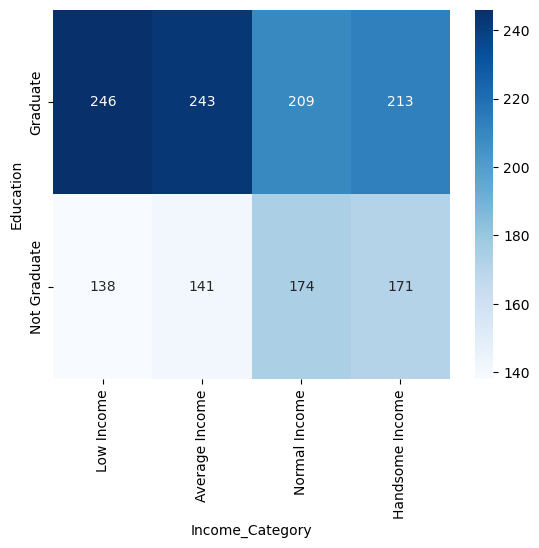

In [70]:
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.show()

## -2 Data_Set

In [71]:
adult = pd.read_csv('adult.csv')
adult

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [72]:
adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [73]:
adult.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [74]:
adult.isna().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [75]:
adult.age.unique(), adult.age.dtype, adult.age.min(), adult.age.max()

(array([25, 38, 28, 44, 18, 34, 29, 63, 24, 55, 65, 36, 26, 58, 48, 43, 20,
        37, 40, 72, 45, 22, 23, 54, 32, 46, 56, 17, 39, 52, 21, 42, 33, 30,
        47, 41, 19, 69, 50, 31, 59, 49, 51, 27, 57, 61, 64, 79, 73, 53, 77,
        80, 62, 35, 68, 66, 75, 60, 67, 71, 70, 90, 81, 74, 78, 82, 83, 85,
        76, 84, 89, 88, 87, 86]),
 dtype('int64'),
 17,
 90)

In [76]:
bins = [16,19,30,40,60,90]
adult['Age_Cetogry'] = pd.cut(x=adult.age,bins=bins, labels=['Teenagers', 'Early Adulthood', 'Settling Period', 'Middle Adulthood','Senior Years'])
adult.Age_Cetogry.value_counts()

Age_Cetogry
Middle Adulthood    16605
Early Adulthood     13283
Settling Period     12838
Senior Years         3606
Teenagers            2510
Name: count, dtype: int64

<Axes: xlabel='Age_Cetogry'>

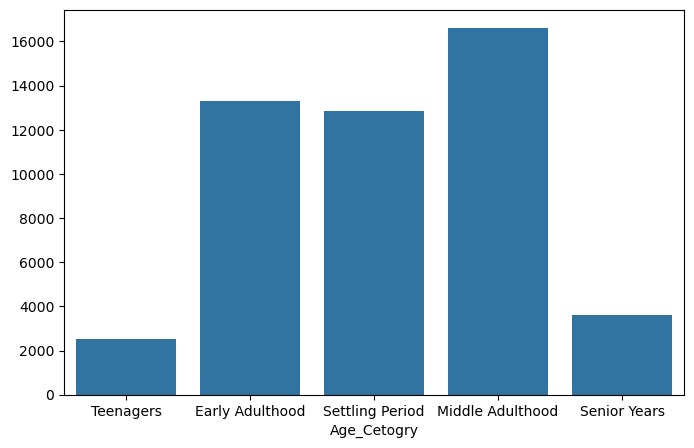

In [77]:
plt.figure(figsize=(8,5))
sns.barplot(x=adult.Age_Cetogry.value_counts().index,y=adult.Age_Cetogry.value_counts().values, )

In [78]:
adult.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income', 'Age_Cetogry'],
      dtype='object')

In [79]:
adult.workclass.unique(), adult.workclass.mode()[0]

(array(['Private', 'Local-gov', '?', 'Self-emp-not-inc', 'Federal-gov',
        'State-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked'],
       dtype=object),
 'Private')

In [80]:
adult.workclass.isin(['?']).mean()*100

np.float64(5.7307235575938735)

In [81]:
# i dontfill nan value and never drop bcz tehre is 5.7 percent values are nan an im not properly sure tat they all are private class i analyze other coloumn which effect tis class whic can be helpfull for me that what class i give this nana by the basis of roup but in this data the private class is greater on every group so i dont feel good to give more private class to other so i give it a new class whoch is unknown_class and if i drop the nan value so 5.7 percent data is huge which is reduce data and im not want to reduce client data
adult.workclass = adult.workclass.replace('?', np.nan)
adult.workclass = adult.workclass.fillna('unknown_class')

In [82]:
adult[adult.occupation == '?'].workclass.unique()

array(['unknown_class', 'Never-worked'], dtype=object)

In [83]:
adult.loc[adult['workclass'] == 'Never-worked', 'occupation'] = 'unknown_occupation'

In [84]:
adult.occupation.replace('?', )

C:\Users\HP\AppData\Local\Temp\ipykernel_3776\3930413142.py:1: FutureWarning: Series.replace without 'value' and with non-dict-like 'to_replace' is deprecated and will raise in a future version. Explicitly specify the new values instead.
  adult.occupation.replace('?', )


0        Machine-op-inspct
1          Farming-fishing
2          Protective-serv
3        Machine-op-inspct
4        Machine-op-inspct
               ...        
48837         Tech-support
48838    Machine-op-inspct
48839         Adm-clerical
48840         Adm-clerical
48841      Exec-managerial
Name: occupation, Length: 48842, dtype: object

In [85]:
adult.occupation.unique()

array(['Machine-op-inspct', 'Farming-fishing', 'Protective-serv', '?',
       'Other-service', 'Prof-specialty', 'Craft-repair', 'Adm-clerical',
       'Exec-managerial', 'Tech-support', 'Sales', 'Priv-house-serv',
       'Transport-moving', 'Handlers-cleaners', 'Armed-Forces',
       'unknown_occupation'], dtype=object)

In [86]:
adult.loc[(adult.age < 18) & (adult.occupation == '?'), 'occupation'] = 'Sales'

In [87]:
(adult.occupation == '?').sum() 

np.int64(2702)

In [88]:
adult.education.unique()

array(['11th', 'HS-grad', 'Assoc-acdm', 'Some-college', '10th',
       'Prof-school', '7th-8th', 'Bachelors', 'Masters', 'Doctorate',
       '5th-6th', 'Assoc-voc', '9th', '12th', '1st-4th', 'Preschool'],
      dtype=object)

In [89]:
adult.loc[(adult.education == '11th') & (adult.age > 18) & (adult.age < 25) & (adult.occupation == '?'), 'occupation'] = 'Other-service'

In [90]:
less_than_11th = ['10th', '9th', '7th-8th', '5th-6th', '1st-4th', 'Preschool']
adult.loc[adult.education.isin(less_than_11th) & (adult.occupation == '?') & (adult.age < 25), 'occupation' ] = 'Other-service'

In [91]:
(adult.occupation == '?').sum()

np.int64(2626)

In [92]:
adult.occupation = adult.occupation.replace('?','unknown_occupation')
(adult.occupation == '?').sum()

np.int64(0)

In [93]:
wg = adult.groupby(['workclass', 'Age_Cetogry']).size().reset_index(name='count')
wg.head(2)

C:\Users\HP\AppData\Local\Temp\ipykernel_3776\4198467255.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wg = adult.groupby(['workclass', 'Age_Cetogry']).size().reset_index(name='count')


,workclass,Age_Cetogry,count
0,Federal-gov,Teenagers,13
1,Federal-gov,Early Adulthood,220


<Axes: xlabel='workclass', ylabel='count'>

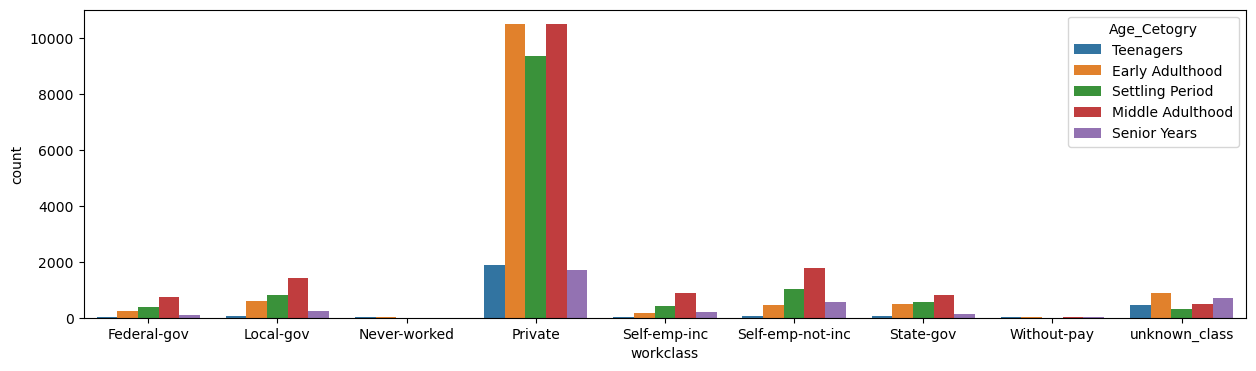

In [94]:
plt.figure(figsize=(15,4))
sns.barplot(data=wg, x='workclass', y='count', hue='Age_Cetogry' )

In [95]:
adult.education.isna().sum(), adult.education.unique()

(np.int64(0),
 array(['11th', 'HS-grad', 'Assoc-acdm', 'Some-college', '10th',
        'Prof-school', '7th-8th', 'Bachelors', 'Masters', 'Doctorate',
        '5th-6th', 'Assoc-voc', '9th', '12th', '1st-4th', 'Preschool'],
       dtype=object))

In [96]:
adult['educational-num'], adult['educational-num'].unique()

(0         7
 1         9
 2        12
 3        10
 4        10
          ..
 48837    12
 48838     9
 48839     9
 48840     9
 48841     9
 Name: educational-num, Length: 48842, dtype: int64,
 array([ 7,  9, 12, 10,  6, 15,  4, 13, 14, 16,  3, 11,  5,  8,  2,  1]))

In [97]:
adult['marital-status'].unique(), adult['marital-status'].isna().sum

(array(['Never-married', 'Married-civ-spouse', 'Widowed', 'Divorced',
        'Separated', 'Married-spouse-absent', 'Married-AF-spouse'],
       dtype=object),
 <bound method Series.sum of 0        False
 1        False
 2        False
 3        False
 4        False
          ...  
 48837    False
 48838    False
 48839    False
 48840    False
 48841    False
 Name: marital-status, Length: 48842, dtype: bool>)

In [98]:
adult.relationship.unique(), adult.relationship.isna().sum()

(array(['Own-child', 'Husband', 'Not-in-family', 'Unmarried', 'Wife',
        'Other-relative'], dtype=object),
 np.int64(0))

In [99]:
adult.race.unique(), adult.race.isna().sum()

(array(['Black', 'White', 'Asian-Pac-Islander', 'Other',
        'Amer-Indian-Eskimo'], dtype=object),
 np.int64(0))

In [100]:
adult.gender.unique(), adult.gender.isna().sum()

(array(['Male', 'Female'], dtype=object), np.int64(0))

In [101]:
adult['capital-gain'].unique(), adult['capital-gain'].isna().sum(), adult['capital-gain'].dtype

(array([    0,  7688,  3103,  6418,  7298,  3908, 14084,  5178, 15024,
        99999,  2597,  2907,  4650,  6497,  1055,  5013, 27828,  4934,
         4064,  3674,  2174, 10605,  3418,   114,  2580,  3411,  4508,
         4386,  8614, 13550,  6849,  2463,  3137,  2885,  2964,  1471,
        10566,  2354,  1424,  1455,  3325,  4416, 25236,   594,  2105,
         4787,  2829,   401,  4865,  1264,  1506, 10520,  3464,  2653,
        20051,  4101,  1797,  2407,  3471,  1086,  1848, 14344,  1151,
         2993,  2290, 15020,  9386,  2202,  3818,  2176,  5455, 11678,
         7978,  7262,  6514, 41310,  3456,  7430,  2414,  2062, 34095,
         1831,  6723,  5060, 15831,  2977,  2346,  3273,  2329,  9562,
         2635,  4931,  1731,  6097,   914,  7896,  5556,  1409,  3781,
         3942,  2538,  3887, 25124,  7443,  5721,  1173,  4687,  6612,
         6767,  2961,   991,  2036,  2936,  2050,  1111,  2228, 22040,
         3432,  6360,  2009,  1639, 18481,  2387]),
 np.int64(0),
 dtype('int

In [102]:
adult['capital-loss'].unique(), adult['capital-loss'].isna().sum(), adult['capital-loss'].dtype

(array([   0, 1721, 1876, 2415, 1887,  625, 1977, 2057, 1429, 1590, 1485,
        2051, 2377, 1672, 1628, 1902, 1602, 1741, 2444, 1408, 2001, 2042,
        1740, 1825, 1848, 1719, 3004, 2179, 1573, 2205, 1258, 2339, 1726,
        2258, 1340, 1504, 2559, 1668, 1974, 1980, 1564, 2547, 2002, 1669,
        1617,  323, 3175, 2472, 2174, 1579, 2129, 1510, 1735, 2282, 1870,
        1411, 1911, 1651, 1092, 1762, 2457, 2231, 2238,  653, 1138, 2246,
        2603, 2392, 1944, 1380, 2465, 1421, 3770, 1594,  213, 2149, 2824,
        1844, 2467, 2163, 1816, 1648, 2206, 2352,  419, 1539,  880,  810,
         974, 4356, 2489, 1755, 3683, 2267, 2080,  155, 3900, 2201, 2754]),
 np.int64(0),
 dtype('int64'))

In [103]:
adult['hours-per-week'].unique(), adult['hours-per-week'].isna().sum(), adult['hours-per-week'].dtype

(array([40, 50, 30, 32, 10, 39, 35, 48, 25, 20, 45, 47,  6, 43, 90, 54, 60,
        38, 36, 18, 24, 44, 56, 28, 16, 41, 22, 55, 14, 33, 37,  8, 12, 70,
        15, 75, 52, 84, 42, 80, 68, 99, 65,  5, 17, 72, 53, 29, 96, 21, 46,
         3,  1, 23, 49, 67, 76,  7,  2, 58, 26, 34,  4, 51, 78, 63, 31, 92,
        77, 27, 85, 13, 19, 98, 62, 66, 57, 11, 86, 59,  9, 64, 73, 61, 88,
        79, 89, 74, 69, 87, 97, 94, 82, 91, 81, 95]),
 np.int64(0),
 dtype('int64'))

In [104]:
adult['native-country'].unique(), adult['native-country'].isna().sum(), adult['native-country'].dtype
adult['native-country'] = adult['native-country'].replace('?',np.nan)

In [105]:
adult['native-country'].fillna(adult.groupby('race')['native-country'].transform(lambda x: x.mode()[0]), inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_3776\1690170409.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adult['native-country'].fillna(adult.groupby('race')['native-country'].transform(lambda x: x.mode()[0]), inplace=True)


In [106]:
adult['native-country'].isna().sum()

np.int64(0)

In [107]:
adult.income.isna().sum(), adult.income.unique()

(np.int64(0), array(['<=50K', '>50K'], dtype=object))

In [108]:
ei = adult.groupby(['education','income']).size().reset_index(name='count')
ei.head(2)

,education,income,count
0,10th,<=50K,1302
1,10th,>50K,87


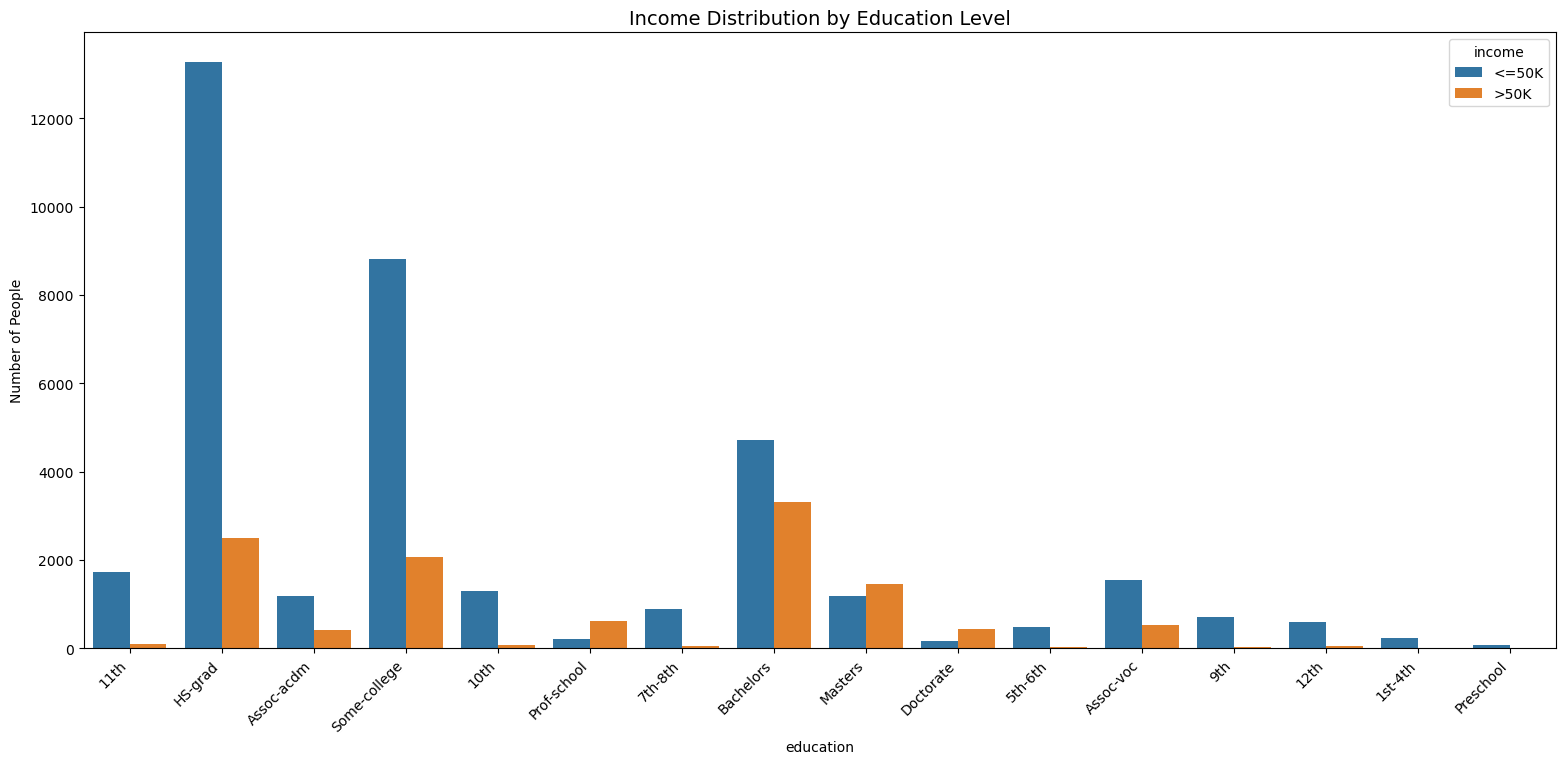

In [109]:
plt.figure(figsize=(19,8))
sns.countplot(data=adult, x='education', hue='income') 

plt.xticks(rotation=45, ha='right')
plt.title("Income Distribution by Education Level", fontsize=14)
plt.ylabel("Number of People")
plt.show()

In [110]:
adult['hours-per-week'].unique()

array([40, 50, 30, 32, 10, 39, 35, 48, 25, 20, 45, 47,  6, 43, 90, 54, 60,
       38, 36, 18, 24, 44, 56, 28, 16, 41, 22, 55, 14, 33, 37,  8, 12, 70,
       15, 75, 52, 84, 42, 80, 68, 99, 65,  5, 17, 72, 53, 29, 96, 21, 46,
        3,  1, 23, 49, 67, 76,  7,  2, 58, 26, 34,  4, 51, 78, 63, 31, 92,
       77, 27, 85, 13, 19, 98, 62, 66, 57, 11, 86, 59,  9, 64, 73, 61, 88,
       79, 89, 74, 69, 87, 97, 94, 82, 91, 81, 95])

In [111]:
pd.qcut(adult['hours-per-week'], q=4, duplicates='drop')

0        (0.999, 40.0]
1         (45.0, 99.0]
2        (0.999, 40.0]
3        (0.999, 40.0]
4        (0.999, 40.0]
             ...      
48837    (0.999, 40.0]
48838    (0.999, 40.0]
48839    (0.999, 40.0]
48840    (0.999, 40.0]
48841    (0.999, 40.0]
Name: hours-per-week, Length: 48842, dtype: category
Categories (3, interval[float64, right]): [(0.999, 40.0] < (40.0, 45.0] < (45.0, 99.0]]

In [112]:
pd.qcut(adult['hours-per-week'], q=4, labels=['low_hour', 'normal_hour', 'average_hours'], duplicates='drop')

0             low_hour
1        average_hours
2             low_hour
3             low_hour
4             low_hour
             ...      
48837         low_hour
48838         low_hour
48839         low_hour
48840         low_hour
48841         low_hour
Name: hours-per-week, Length: 48842, dtype: category
Categories (3, object): ['low_hour' < 'normal_hour' < 'average_hours']

In [113]:
adult.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income', 'Age_Cetogry'],
      dtype='object')

Text(0.5, 1.0, 'Income of Diffrent Age Ceatgory')

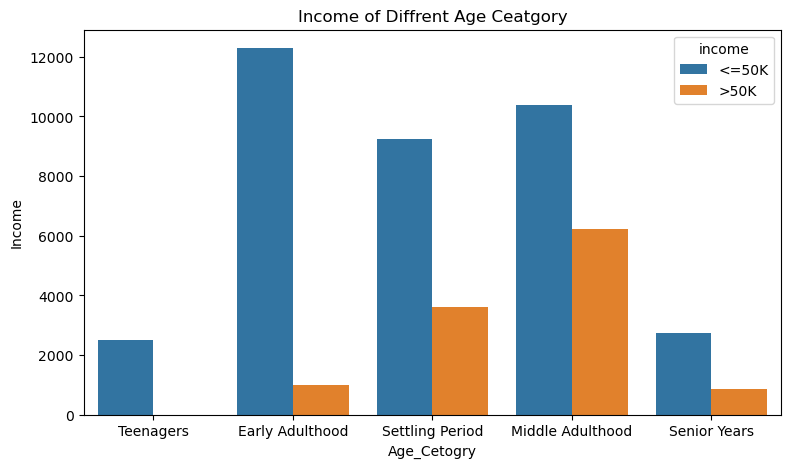

In [114]:
plt.figure(figsize=(9,5))
sns.countplot(data=adult, x='Age_Cetogry', hue='income')
plt.ylabel('Income')
plt.title("Income of Diffrent Age Ceatgory")

# -3 Data Set

In [2]:
hb = pd.read_csv('hotel_booking.csv')
hb.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [3]:
hb.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [4]:
hb.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'name', 'email',
       'phone-number', 'credit_card'],
      dtype='object')

In [5]:
hb.hotel.unique()
hb.hotel.value_counts().reset_index()

,hotel,count
0,City Hotel,79330
1,Resort Hotel,40060


In [6]:
hb.is_canceled.unique(), hb.is_canceled.dtype

(array([0, 1]), dtype('int64'))

In [7]:
hb.lead_time.isna().sum(), hb.lead_time.dtype, hb.lead_time.unique()

(np.int64(0),
 dtype('int64'),
 array([342, 737,   7,  13,  14,   0,   9,  85,  75,  23,  35,  68,  18,
         37,  12,  72, 127,  78,  48,  60,  77,  99, 118,  95,  96,  69,
         45,  40,  15,  36,  43,  70,  16, 107,  47, 113,  90,  50,  93,
         76,   3,   1,  10,   5,  17,  51,  71,  63,  62, 101,   2,  81,
        368, 364, 324,  79,  21, 109, 102,   4,  98,  92,  26,  73, 115,
         86,  52,  29,  30,  33,  32,   8, 100,  44,  80,  97,  64,  39,
         34,  27,  82,  94, 110, 111,  84,  66, 104,  28, 258, 112,  65,
         67,  55,  88,  54, 292,  83, 105, 280, 394,  24, 103, 366, 249,
         22,  91,  11, 108, 106,  31,  87,  41, 304, 117,  59,  53,  58,
        116,  42, 321,  38,  56,  49, 317,   6,  57,  19,  25, 315, 123,
         46,  89,  61, 312, 299, 130,  74, 298, 119,  20, 286, 136, 129,
        124, 327, 131, 460, 140, 114, 139, 122, 137, 126, 120, 128, 135,
        150, 143, 151, 132, 125, 157, 147, 138, 156, 164, 346, 159, 160,
        161, 333, 38

In [8]:
hb.arrival_date_year.unique(), hb.arrival_date_year.dtype

(array([2015, 2016, 2017]), dtype('int64'))

In [9]:
hb.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'name', 'email',
       'phone-number', 'credit_card'],
      dtype='object')

In [10]:
hb.arrival_date_month.unique(), hb.arrival_date_month.dtype

(array(['July', 'August', 'September', 'October', 'November', 'December',
        'January', 'February', 'March', 'April', 'May', 'June'],
       dtype=object),
 dtype('O'))

In [11]:
hb.arrival_date_week_number.unique(), hb.arrival_date_week_number.dtype

(array([27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,
        44, 45, 46, 47, 48, 49, 50, 51, 52, 53,  1,  2,  3,  4,  5,  6,  7,
         8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24,
        25, 26]),
 dtype('int64'))

In [12]:
hb.arrival_date_day_of_month.unique(), hb.arrival_date_day_of_month.dtype

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]),
 dtype('int64'))

In [13]:
hb.stays_in_weekend_nights.unique(), hb.stays_in_weekend_nights.dtype

(array([ 0,  1,  2,  4,  3,  6, 13,  8,  5,  7, 12,  9, 16, 18, 19, 10, 14]),
 dtype('int64'))

In [14]:
hb.stays_in_week_nights.unique(), hb.stays_in_week_nights.dtype

(array([ 0,  1,  2,  3,  4,  5, 10, 11,  8,  6,  7, 15,  9, 12, 33, 20, 14,
        16, 21, 13, 30, 19, 24, 40, 22, 42, 50, 25, 17, 32, 26, 18, 34, 35,
        41]),
 dtype('int64'))

In [15]:
hb.adults.unique(), hb.adults.dtype

(array([ 2,  1,  3,  4, 40, 26, 50, 27, 55,  0, 20,  6,  5, 10]),
 dtype('int64'))

In [16]:
hb.children.isna().sum()

np.int64(4)

In [17]:
hb.children.fillna(hb.children.median(),inplace=True)
hb.children = hb.children.astype(int)

C:\Users\HP\AppData\Local\Temp\ipykernel_13616\3546990095.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  hb.children.fillna(hb.children.median(),inplace=True)


In [18]:
hb.meal.unique(), hb.meal.mode()[0], hb.meal.isin(['Undefined']).mean()*100

(array(['BB', 'FB', 'HB', 'SC', 'Undefined'], dtype=object),
 'BB',
 np.float64(0.9791439819080325))

In [19]:
hb.meal = hb.meal.replace('Undefined','BB')

In [20]:
hb.country.unique(), hb.country.mode()[0], hb.country.isna().sum(), hb.country.isna().mean()*100

(array(['PRT', 'GBR', 'USA', 'ESP', 'IRL', 'FRA', nan, 'ROU', 'NOR', 'OMN',
        'ARG', 'POL', 'DEU', 'BEL', 'CHE', 'CN', 'GRC', 'ITA', 'NLD',
        'DNK', 'RUS', 'SWE', 'AUS', 'EST', 'CZE', 'BRA', 'FIN', 'MOZ',
        'BWA', 'LUX', 'SVN', 'ALB', 'IND', 'CHN', 'MEX', 'MAR', 'UKR',
        'SMR', 'LVA', 'PRI', 'SRB', 'CHL', 'AUT', 'BLR', 'LTU', 'TUR',
        'ZAF', 'AGO', 'ISR', 'CYM', 'ZMB', 'CPV', 'ZWE', 'DZA', 'KOR',
        'CRI', 'HUN', 'ARE', 'TUN', 'JAM', 'HRV', 'HKG', 'IRN', 'GEO',
        'AND', 'GIB', 'URY', 'JEY', 'CAF', 'CYP', 'COL', 'GGY', 'KWT',
        'NGA', 'MDV', 'VEN', 'SVK', 'FJI', 'KAZ', 'PAK', 'IDN', 'LBN',
        'PHL', 'SEN', 'SYC', 'AZE', 'BHR', 'NZL', 'THA', 'DOM', 'MKD',
        'MYS', 'ARM', 'JPN', 'LKA', 'CUB', 'CMR', 'BIH', 'MUS', 'COM',
        'SUR', 'UGA', 'BGR', 'CIV', 'JOR', 'SYR', 'SGP', 'BDI', 'SAU',
        'VNM', 'PLW', 'QAT', 'EGY', 'PER', 'MLT', 'MWI', 'ECU', 'MDG',
        'ISL', 'UZB', 'NPL', 'BHS', 'MAC', 'TGO', 'TWN', 'DJI', 'STP',
  

In [21]:
hb.country.fillna(hb.country.mode()[0], inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_13616\4107465112.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  hb.country.fillna(hb.country.mode()[0], inplace=True)


In [22]:
hb.market_segment.unique(), hb.market_segment.isin(['Undefined']).mean()*100, hb.market_segment.mode()[0]

(array(['Direct', 'Corporate', 'Online TA', 'Offline TA/TO',
        'Complementary', 'Groups', 'Undefined', 'Aviation'], dtype=object),
 np.float64(0.0016751821760616465),
 'Online TA')

In [23]:
hb.market_segment = hb.market_segment.replace('Undefined','Online TA')

In [24]:
hb.distribution_channel.unique(), hb.distribution_channel.isin(['Undefined']).mean()*100, hb.distribution_channel.mode()[0]

(array(['Direct', 'Corporate', 'TA/TO', 'Undefined', 'GDS'], dtype=object),
 np.float64(0.004187955440154116),
 'TA/TO')

In [25]:
hb.distribution_channel = hb.distribution_channel.replace('Undefined','TA/TO')

In [26]:
print('is_repeated_guest = ',hb.is_repeated_guest.unique())

is_repeated_guest =  [0 1]


In [27]:
print('previous_cancellations = ', hb.previous_cancellations.unique())

previous_cancellations =  [ 0  1  2  3 26 25 14  4 24 19  5 21  6 13 11]


In [28]:
print('previous_bookings_not_canceled = ', hb.previous_bookings_not_canceled.unique())

previous_bookings_not_canceled =  [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 20 21 22 23 24
 25 27 28 29 30 19 26 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72]


In [29]:
print('reserved_room_type =', hb.reserved_room_type.unique())  

reserved_room_type = ['C' 'A' 'D' 'E' 'G' 'F' 'H' 'L' 'P' 'B']


In [30]:
 print('assigned_room_type = ', hb.assigned_room_type.unique())

assigned_room_type =  ['C' 'A' 'D' 'E' 'G' 'F' 'I' 'B' 'H' 'P' 'L' 'K']


In [31]:
hb.deposit_type.unique()

array(['No Deposit', 'Refundable', 'Non Refund'], dtype=object)

In [32]:
hb.agent.isna().mean()*100

np.float64(13.686238378423655)

In [33]:
hb.agent.fillna(0, inplace=True)
hb.agent = hb.agent.astype(int)

C:\Users\HP\AppData\Local\Temp\ipykernel_13616\952063881.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  hb.agent.fillna(0, inplace=True)


In [34]:
hb.company.isna().mean()*100

np.float64(94.30689337465449)

In [35]:
hb.company.fillna(0, inplace=True)
hb.company = hb.company.astype(int)

C:\Users\HP\AppData\Local\Temp\ipykernel_13616\329933599.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  hb.company.fillna(0, inplace=True)


In [36]:
hb.days_in_waiting_list.unique()

array([  0,  50,  47,  65, 122,  75, 101, 150, 125,  14,  60,  34, 100,
        22, 121,  61,  39,   5,   1,   8, 107,  43,  52,   2,  11, 142,
       116,  13,  44,  97,  83,   4, 113,  18,  20, 185,  93, 109,   6,
        37, 105, 154,  64,  99,  38,  48,  33,  77,  21,  80,  59,  40,
        58,  89,  53,  49,  69,  87,  91,  57, 111,  79,  98,  85,  63,
        15,   3,  41, 224,  31,  56, 187, 176,  71,  55,  96, 236, 259,
       207, 215, 160, 120,  30,  32,  27,  62,  24, 108, 147, 379,  70,
        35, 178, 330, 223, 174, 162, 391,  68, 193,  10,  76,  16,  28,
         9, 165,  17,  25,  46,   7,  84, 175, 183,  23, 117,  12,  54,
        26,  73,  45,  19,  42,  72,  81,  92,  74, 167,  36])

In [37]:
hb.customer_type.unique()

array(['Transient', 'Contract', 'Transient-Party', 'Group'], dtype=object)

In [38]:
hb.adr.unique()

array([  0.  ,  75.  ,  98.  , ..., 266.75, 209.25, 157.71])

In [39]:
hb.required_car_parking_spaces.unique()

array([0, 1, 2, 8, 3])

In [40]:
hb.total_of_special_requests.unique()

array([0, 1, 3, 2, 4, 5])

In [41]:
hb.reservation_status.unique()

array(['Check-Out', 'Canceled', 'No-Show'], dtype=object)

In [42]:
hb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119390 non-null  int64  
 11  babies                          119390 non-null  int64  
 12  meal            

In [43]:
hb.name.unique()

array(['Ernest Barnes', 'Andrea Baker', 'Rebecca Parker', ...,
       'Wesley Aguilar', 'Caroline Conley MD', 'Ariana Michael'],
      dtype=object)

In [44]:
hb.email.unique()

array(['Ernest.Barnes31@outlook.com', 'Andrea_Baker94@aol.com',
       'Rebecca_Parker@comcast.net', ..., 'Mary_Morales@hotmail.com',
       'MD_Caroline@comcast.net', 'Ariana_M@xfinity.com'], dtype=object)

In [45]:
hb.total_of_special_requests.unique()

array([0, 1, 3, 2, 4, 5])

In [46]:
hb.assigned_room_type.unique()

array(['C', 'A', 'D', 'E', 'G', 'F', 'I', 'B', 'H', 'P', 'L', 'K'],
      dtype=object)

In [47]:
hb.distribution_channel.unique()

array(['Direct', 'Corporate', 'TA/TO', 'GDS'], dtype=object)

In [48]:
hb.days_in_waiting_list.unique(), hb.days_in_waiting_list.min(), hb.days_in_waiting_list.max(), hb.days_in_waiting_list.dtype

(array([  0,  50,  47,  65, 122,  75, 101, 150, 125,  14,  60,  34, 100,
         22, 121,  61,  39,   5,   1,   8, 107,  43,  52,   2,  11, 142,
        116,  13,  44,  97,  83,   4, 113,  18,  20, 185,  93, 109,   6,
         37, 105, 154,  64,  99,  38,  48,  33,  77,  21,  80,  59,  40,
         58,  89,  53,  49,  69,  87,  91,  57, 111,  79,  98,  85,  63,
         15,   3,  41, 224,  31,  56, 187, 176,  71,  55,  96, 236, 259,
        207, 215, 160, 120,  30,  32,  27,  62,  24, 108, 147, 379,  70,
         35, 178, 330, 223, 174, 162, 391,  68, 193,  10,  76,  16,  28,
          9, 165,  17,  25,  46,   7,  84, 175, 183,  23, 117,  12,  54,
         26,  73,  45,  19,  42,  72,  81,  92,  74, 167,  36]),
 0,
 391,
 dtype('int64'))

In [49]:
hb.days_in_waiting_list.isna().sum()

np.int64(0)

In [50]:
bins = [0,100,200,300,391]
hb['cday_in_wating_list_ceatogry'] = pd.cut(x=hb.days_in_waiting_list, bins=bins, labels=['lower_class', 'normal_class', 'medium_class', 'upper_class'], include_lowest=True)

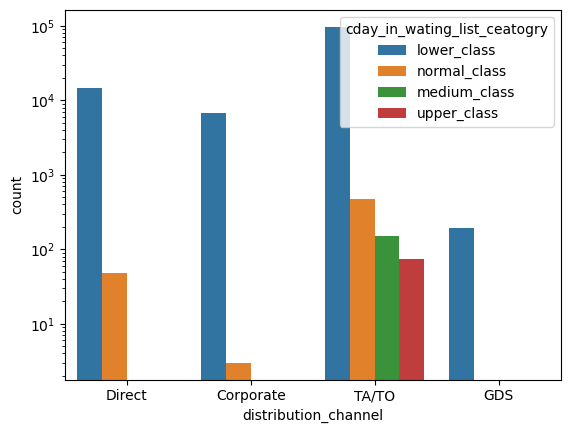

In [51]:
# plt.figure(figsize=(20,6))
sns.countplot(data=hb, x=hb.distribution_channel, hue=hb.cday_in_wating_list_ceatogry)
plt.yscale('log')

In [53]:
hb.is_repeated_guest.unique()

array([0, 1])

In [54]:
hb.is_canceled.unique()

array([0, 1])

In [55]:
rc = hb.groupby(['is_repeated_guest','is_canceled' ]).size().reset_index(name='count')
rc.is_repeated_guest = rc.is_repeated_guest.map({0:'No', 1:'Yes'})
rc.is_canceled = rc.is_canceled.map({0:'No', 1:'Yes'})

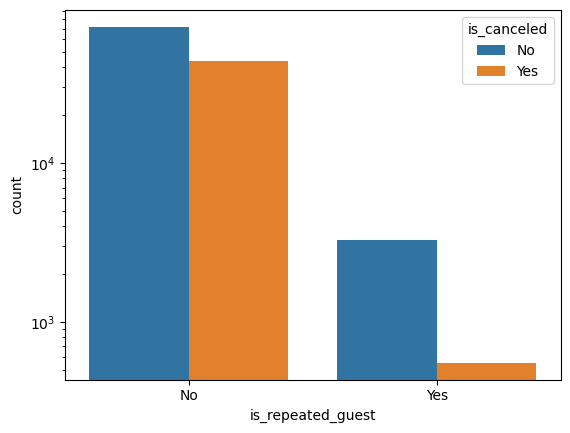

In [56]:
sns.barplot(data=rc, x='is_repeated_guest', y='count', hue='is_canceled')
plt.yscale('log')

In [52]:
hb.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'name', 'email',
       'phone-number', 'credit_card', 'cday_in_wating_list_ceatogry'],
      dtype='object')

In [70]:
hb.meal.unique(), hb.babies.unique(), hb.required_car_parking_spaces.unique(), hb.previous_cancellations.unique(), hb.previous_cancellations.unique(), hb.market_segment.unique(),hb.adults.unique() 

(array(['BB', 'FB', 'HB', 'SC'], dtype=object),
 array([ 0,  1,  2, 10,  9]),
 array([0, 1, 2, 8, 3]),
 array([ 0,  1,  2,  3, 26, 25, 14,  4, 24, 19,  5, 21,  6, 13, 11]),
 array([ 0,  1,  2,  3, 26, 25, 14,  4, 24, 19,  5, 21,  6, 13, 11]),
 array(['Direct', 'Corporate', 'Online TA', 'Offline TA/TO',
        'Complementary', 'Groups', 'Aviation'], dtype=object),
 array([ 2,  1,  3,  4, 40, 26, 50, 27, 55,  0, 20,  6,  5, 10]))

In [62]:
hb.reservation_status.unique()

array(['Check-Out', 'Canceled', 'No-Show'], dtype=object)

<Axes: xlabel='arrival_date_month', ylabel='arrival_date_year'>

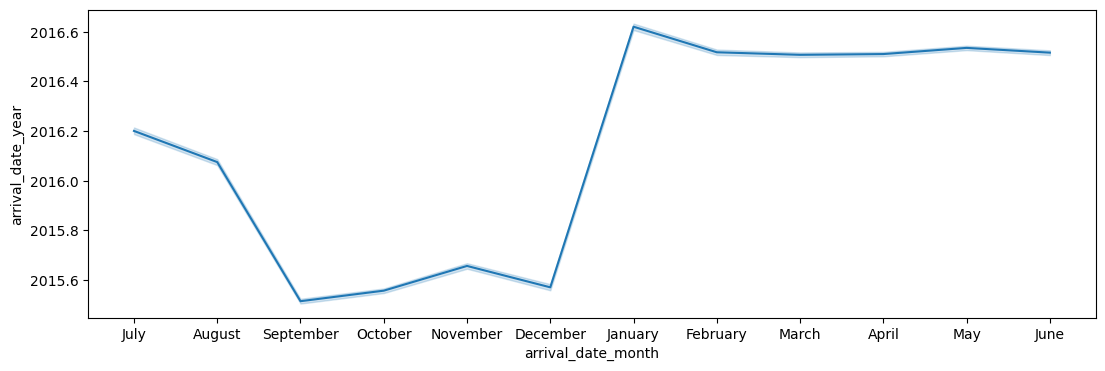

In [75]:
plt.figure(figsize=(13,4))
sns.lineplot(data=hb, y=hb.arrival_date_year, x=hb.arrival_date_month)

<Axes: xlabel='hotel', ylabel='count'>

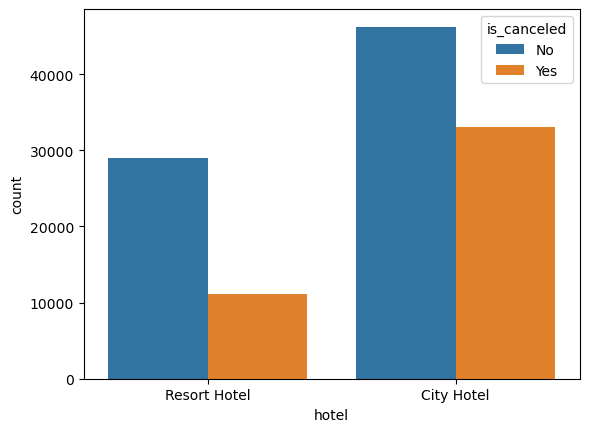

In [82]:
sns.countplot(data=hb, x=hb.hotel, hue=hb.is_canceled.map({0:'No',1:'Yes'}))